In [2]:
'''
Here in this data set, to make sure the model with beneficial mutations is correct, we simulated the beneficial model with setting
the mutation rate of beneficial mutation to be 0, and comparing the data with the previous data got by deleterious only model.


Diploid case
Here N = 2000 and assuming 0% mutations are beneficial.Simulate for 20K generations.
Tried Mitosis, RM, RME10 with mitosis, RME100 with mitosis, RM E1K with mitosis and RM E10K with mitosis.

Comparing with simulation got by deleterious only model.


This set of data was collected by single processor.


'''

'\nHere in this data set,\nUnder diploid single locus case,\nOnce we modelled sex, \nInstead of assuming the effect of modifier mutation additive, we changed their effect to be dominant (thus with only 1 copy\nof the modifier mutation they can change the mutation rate by 90%) and recessive (thus only with 2 copies of the modifier \nmutation they can change the mutation rate by 90%). \n\nThis is to check whether the segregation process during sex causes the difference between diploid and haploid with L = 200.\n\nHere N = 2000 and assuming 1% mutations are beneficial.Simulate for 20K generations.\nTried Mitosis, RM, RME10 with mitosis, RME100 with mitosis, RM E1K with mitosis and RM E10K with mitosis.\n\nComparing with haploid simulation with Fit L = 200 Mod L =10 Mod Mut Eff = 0.90.\n\nIn this set, 2X means that the initial mutation rate of modifier in haploid model is twice as that in diploid model (as diploid\nhas twice sites comparing to haploid case for the modifiers, so we used a t

In [1]:
from __future__ import division
import numpy as np
from scipy import stats
import scipy.spatial as spa
import numpy.random as rnd
import copy
import time
import pandas as pd
import math
import pickle
import seaborn as sns
import os

In [2]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_bene_mean = []
    total_soma_mu_bene_std = []

    total_soma_mu_dele_mean = []
    total_soma_mu_dele_std = []
    
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_bene_mean = []
        soma_mu_bene_std = []

        soma_mu_dele_mean = []
        soma_mu_dele_std = []
            
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_bene_mean.extend(list(pd.Series(f.SomaMu_Bene_Mean,dtype=float)))
        soma_mu_bene_std.extend(list(pd.Series(f.SomaMu_Bene_Std,dtype=float)))

        soma_mu_dele_mean.extend(list(pd.Series(f.SomaMu_Dele_Mean,dtype=float)))
        soma_mu_dele_std.extend(list(pd.Series(f.SomaMu_Dele_Std,dtype=float)))
        
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_bene_mean.append(soma_mu_bene_mean)
        total_soma_mu_bene_std.append(soma_mu_bene_std)  

        total_soma_mu_dele_mean.append(soma_mu_dele_mean)
        total_soma_mu_dele_std.append(soma_mu_dele_std)
        
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_bene_mean, total_soma_mu_bene_std, \
total_soma_mu_dele_mean, total_soma_mu_dele_std

In [3]:
def get_data2(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_mean = []
    total_soma_mu_std = []
 
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_mean = []
        soma_mu_std = []
        
        soma_genomic_mu_mean = []
        soma_genomic_mu_std = []
        

        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_mean.extend(list(pd.Series(f.SomaMu_Mean,dtype=float)))
        soma_mu_std.extend(list(pd.Series(f.SomaMu_Std,dtype=float)))
        
     
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_mean.append(soma_mu_mean)
        total_soma_mu_std.append(soma_mu_std)  
             
        
    return total_fit_mean, total_fit_std, total_soma_mu_mean, total_soma_mu_std

## N = 2K_Dele Only Model

In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20191219_Evolution of Mu Rate_Single Locus_Dele\Data\1. Diploid\1. Dele Only\N2K_20KG")

In [5]:
bl_fit_file = ['Fit_Mito_SgP2Nucl_N2K_Dele_MuEvo_20KG.csv', 'Fit_RM_SgP2Nucl_N2K_Dele_MuEvo_20KG.csv', \
               'Fit_RME10M_SgP2Nucl_N2K_Dele_MuEvo_20KG.csv', 'Fit_RME100M_SgP2Nucl_N2K_Dele_MuEvo_20KG.csv', \
               'Fit_RME1KM_SgP2Nucl_N2K_Dele_MuEvo_20KG.csv','Fit_RME10KM_SgP2Nucl_N2K_Dele_MuEvo_20KG.csv' ]


bl = get_data2(bl_fit_file)

bl_fit_mean =bl[0]
bl_fit_std = bl[1]

bl_fit_mean =bl[0]
bl_fit_std = bl[1]

bl_sm_mu_mean = bl[2]
bl_sm_mu_std = bl[3]

## N = 2K_With Beneficial Mutation_Set Bene% to 0

In [6]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20200212_Evolution of Mu Rate_Single Locus_1% Bene\Data\1. Diploid\1.1B. Test_0% Bene_Comparing to Dele Only Model")

In [7]:
f005_fit_file = ['Fit_Mito_P2SN_N2K_Bene00_MuEvo_200207.csv', 'Fit_RM_P2SN_N2K_Bene00_MuEvo_200207.csv', \
                 'Fit_RME10M_P2SN_N2K_Bene00_MuEvo_200207.csv', 'Fit_RME100M_P2SN_N2K_Bene00_MuEvo_200207.csv', \
                 'Fit_RME1KM_P2SN_N2K_Bene00_MuEvo_200207.csv', 'Fit_RME10KM_P2SN_N2K_Bene00_MuEvo_200207.csv' ]

f005 = get_data1(f005_fit_file)

f005_fit_mean =f005[0]
f005_fit_std = f005[1]

f005_sm_mu_bene_mean = f005[2]
f005_sm_mu_bene_std = f005[3]

f005_sm_mu_dele_mean = f005[4]
f005_sm_mu_dele_std = f005[5]

In [8]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

In [9]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [10]:
generation_list = []

for i in range(20002):
    generation_list.append(i)
    
print(len(generation_list))

20002


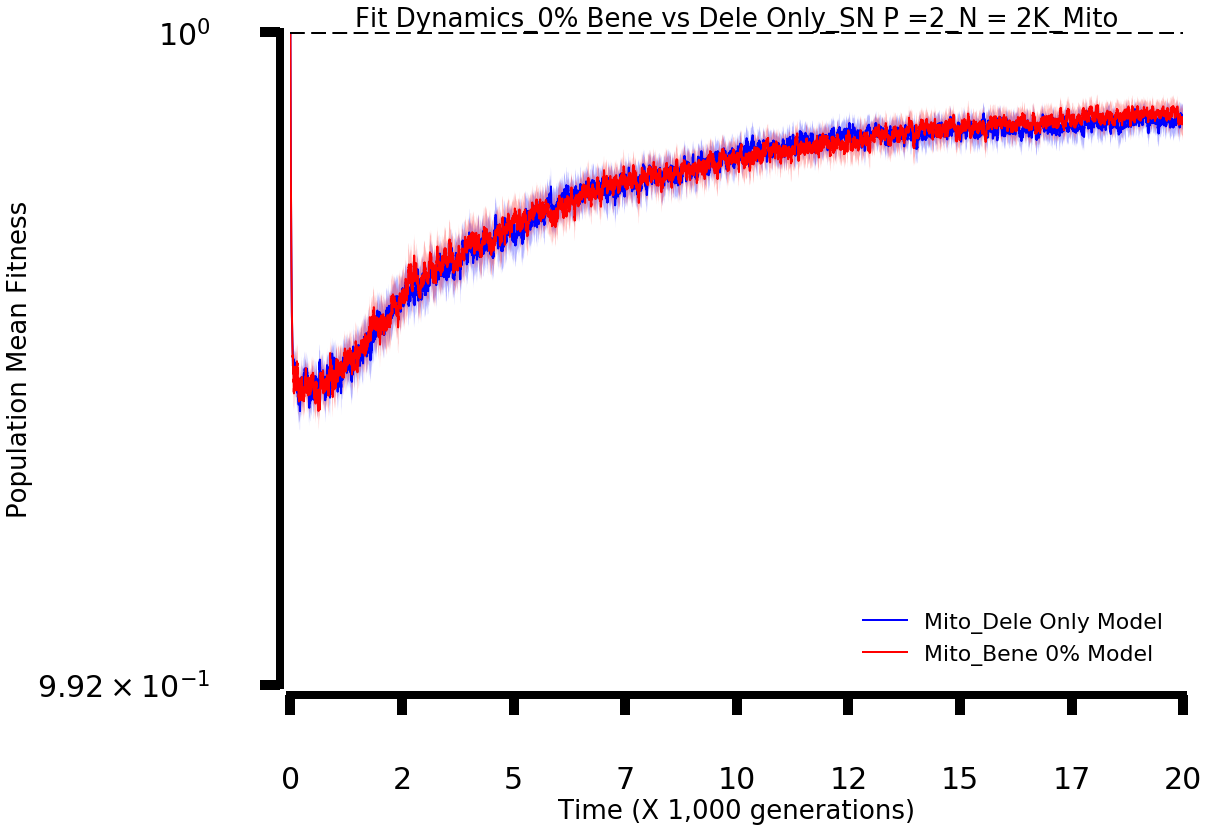

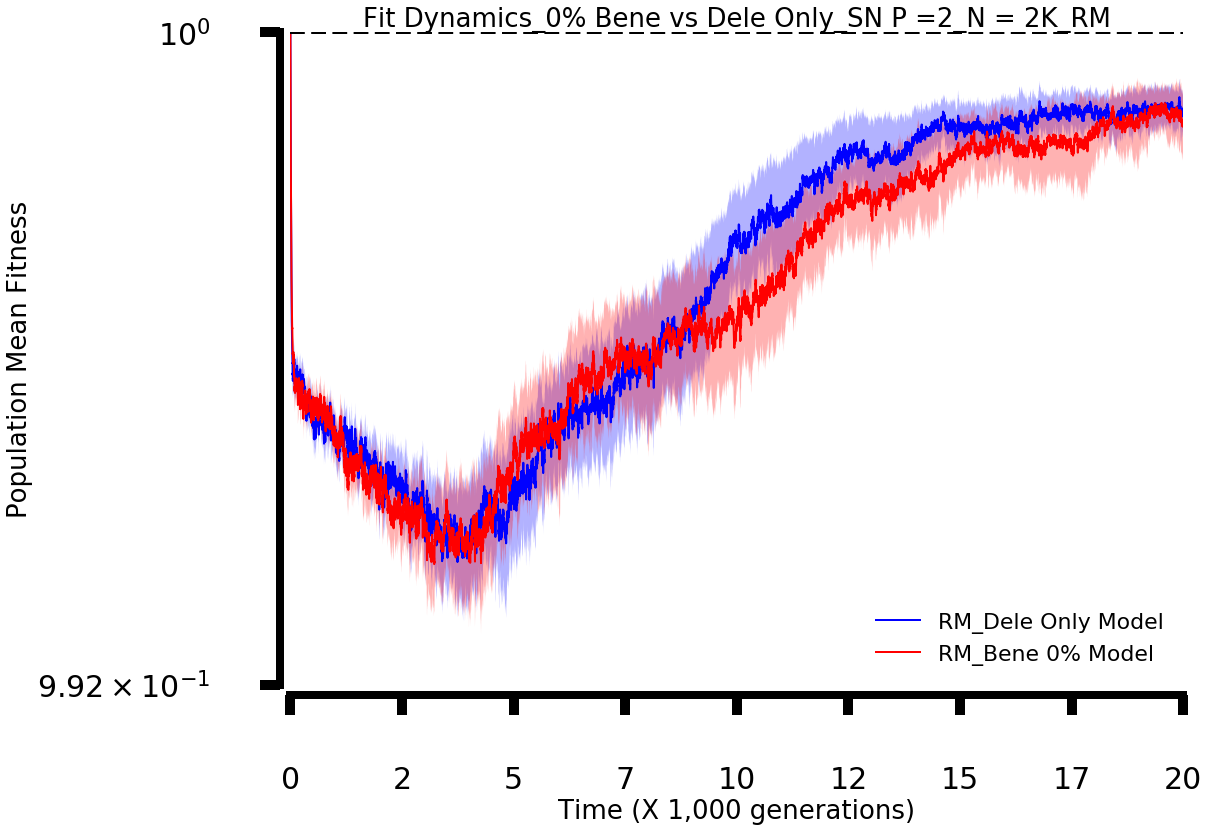

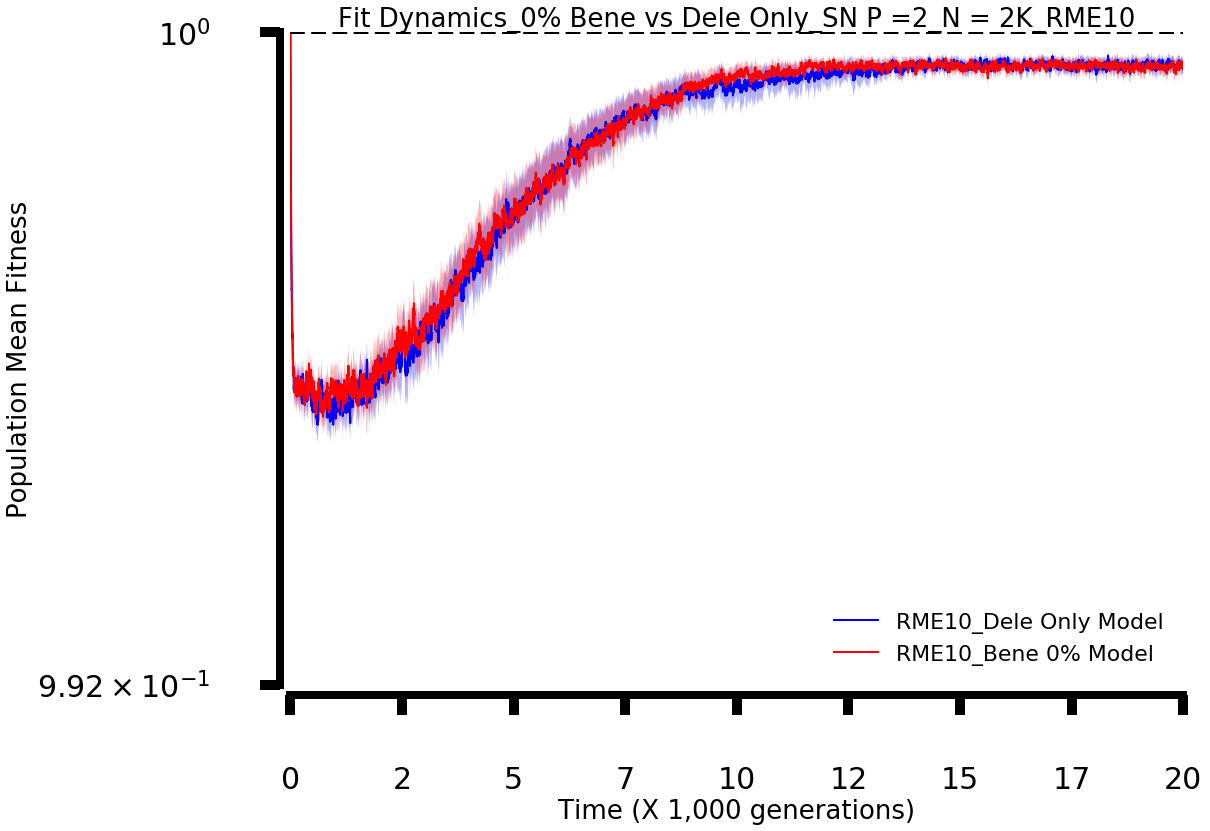

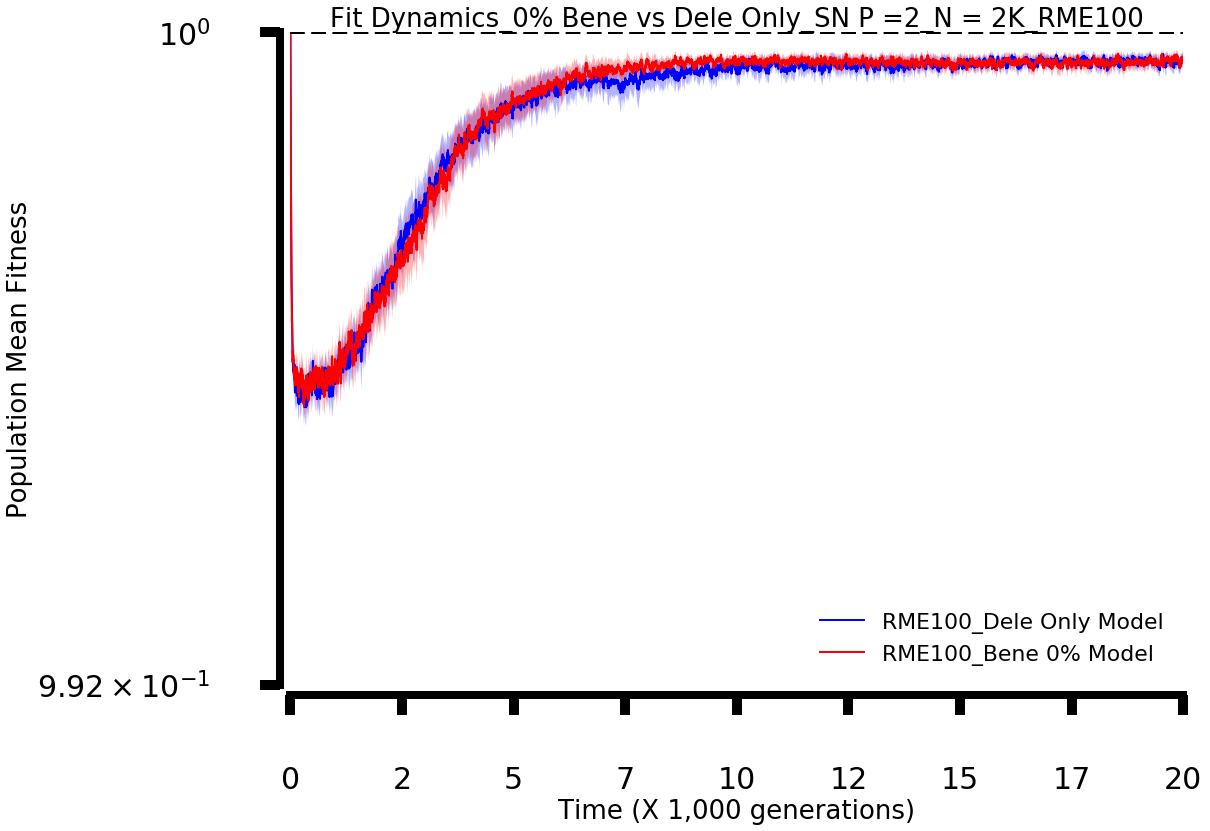

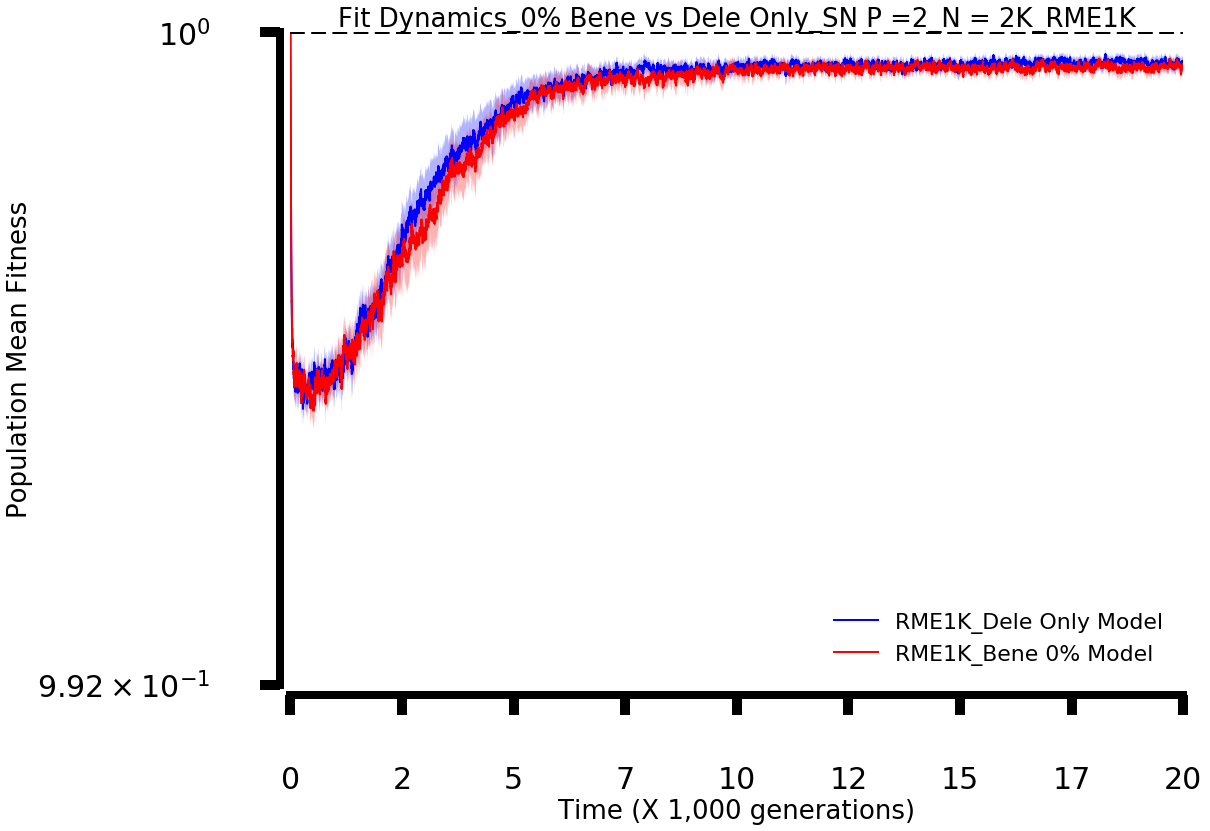

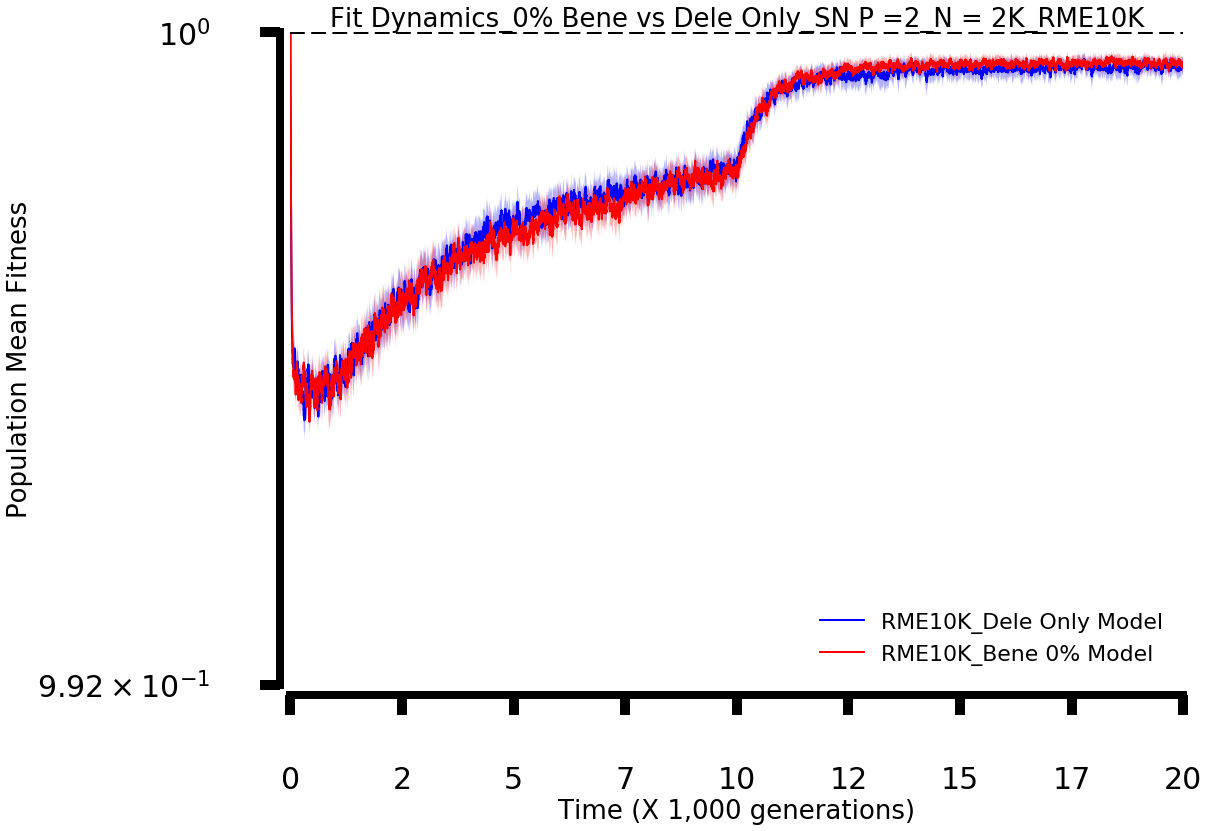

In [11]:
for i in range(6):
    
    
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111)
    publication_figure(ax)
    # ax.scatter(0,0)

    ax.set_xlim(0,20*1000)

    t = generation_list

    a1 = bl_fit_mean[i]
    error_a1 = list(1.98* np.array(bl_fit_std[i])/((100)**0.5))

    a2 = f005_fit_mean[i]
    error_a2 = list(1.98* np.array(f005_fit_std[i])/((100)**0.5))


    ax.set_yscale('log')

    rp_strategy = ['Mito', 'RM', 'RME10', 'RME100', 'RME1K', 'RME10K']


    ax.set_title('Fit Dynamics_0% Bene vs Dele Only_SN P =2_N = 2K_{}'.format(rp_strategy[i]), fontsize =26)
    ax.set_xlabel('Time (X 1,000 generations)', fontsize =26)
    ax.set_ylabel('Population Mean Fitness', fontsize =26)
    
    
    ax.plot(t,a1,'b', label = '{}_Dele Only Model'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='b')


    ax.plot(t,a2,'r', label = '{}_Bene 0% Model'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='r')


 
    plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')

    ax.minorticks_off()

    plt.legend(loc=4, frameon=False, prop={'size':22})
    
    extraticks=[0.992]
    ax.set_yticks(list(ax.get_yticks()) + extraticks)

    ax.set_ylim(0.992, 1)

    plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

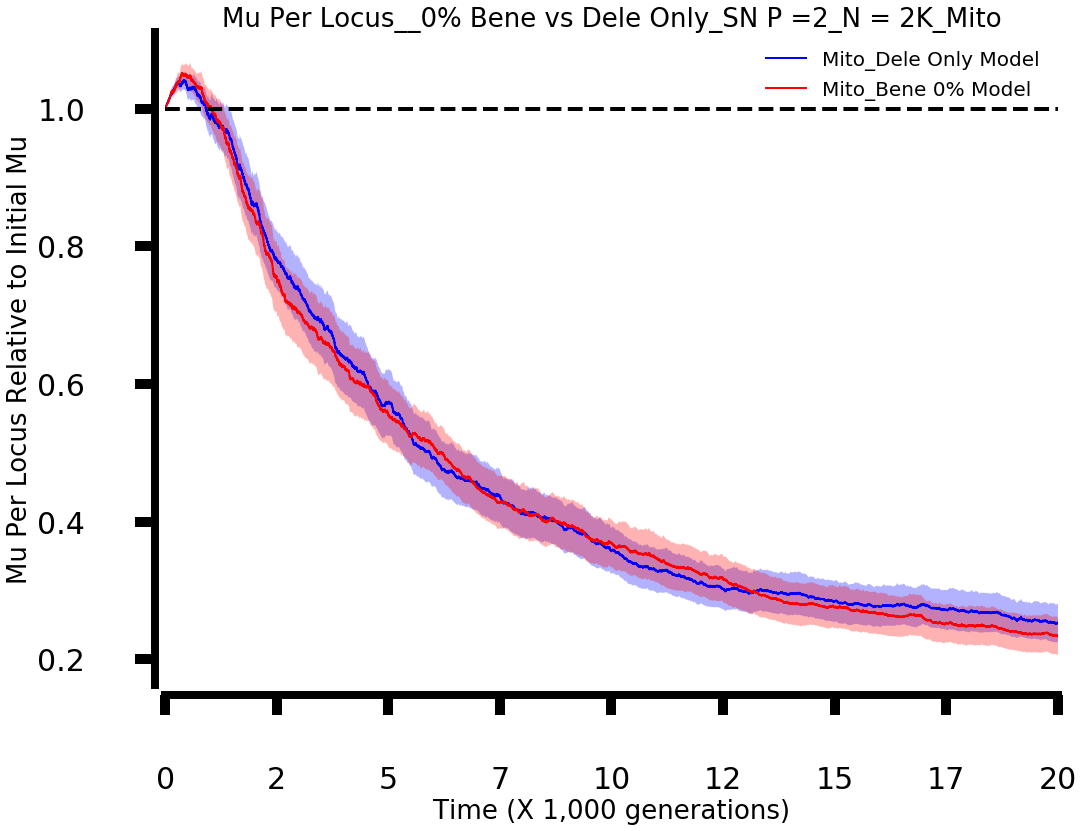

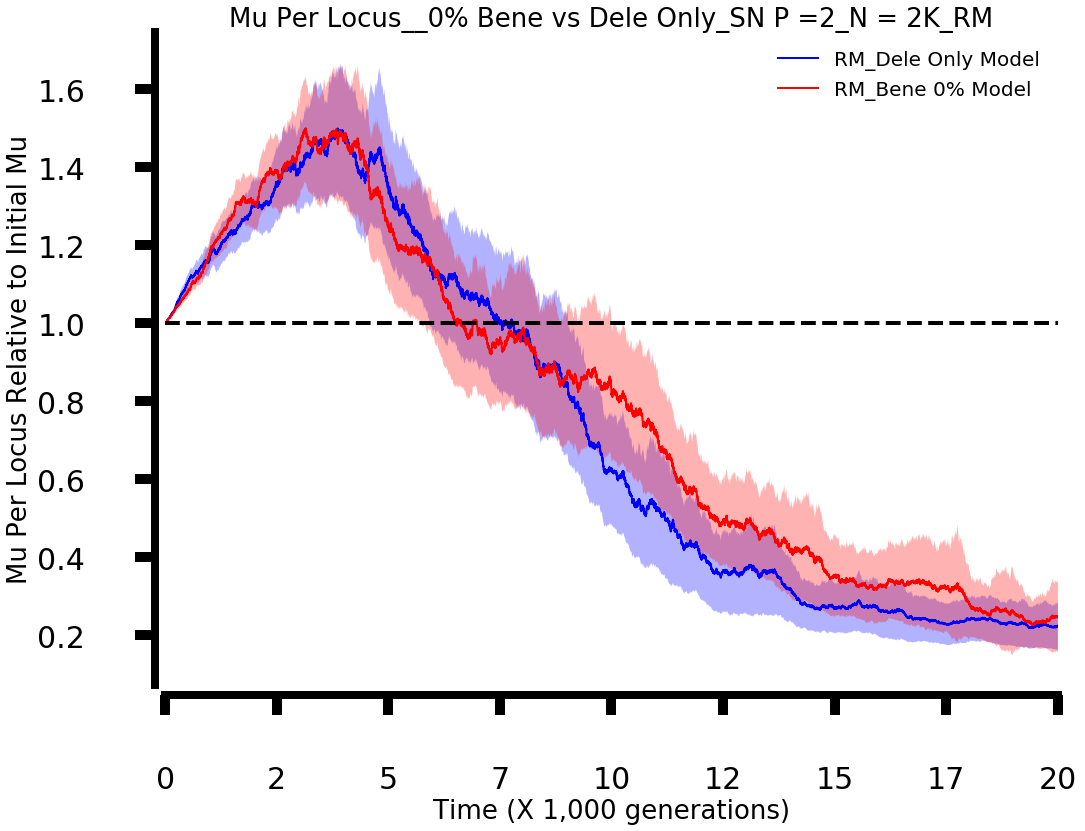

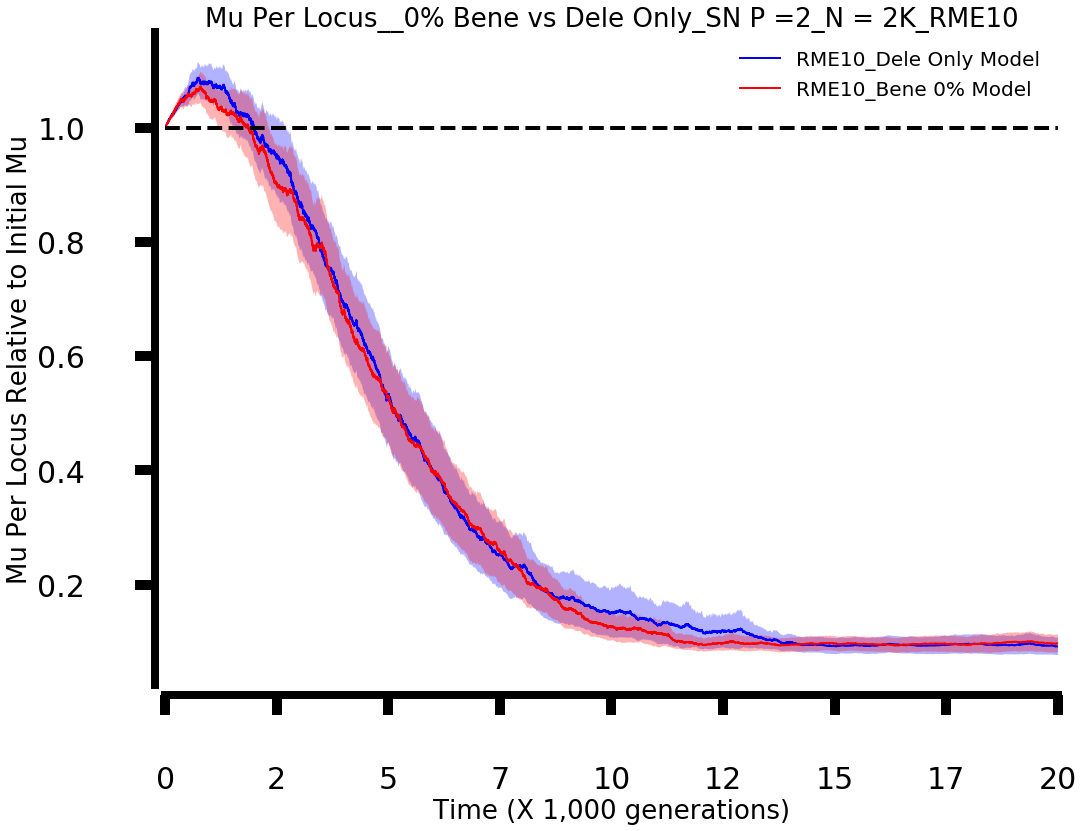

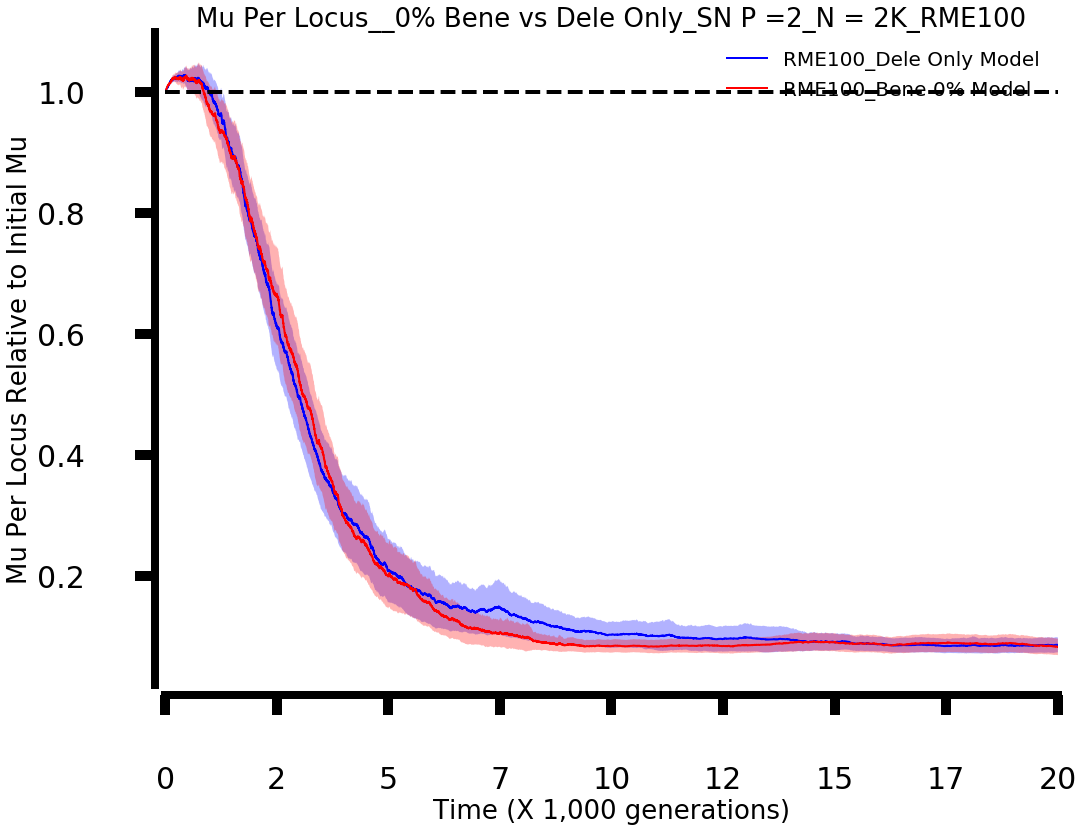

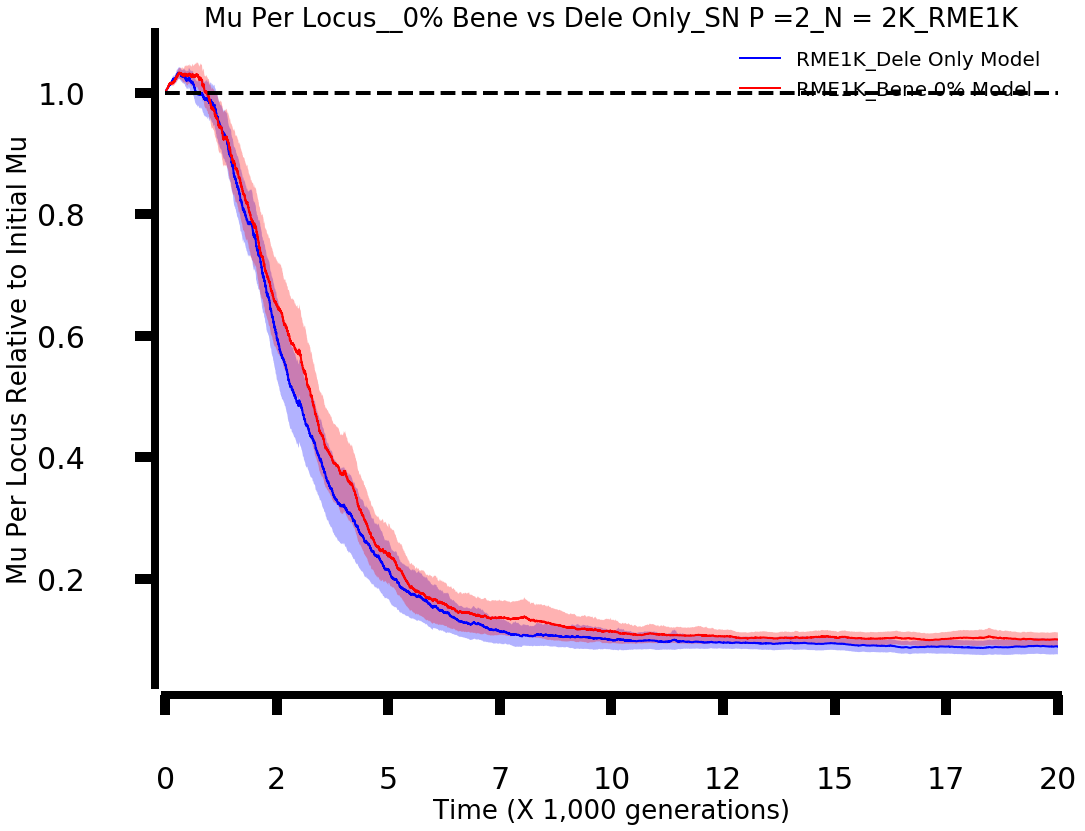

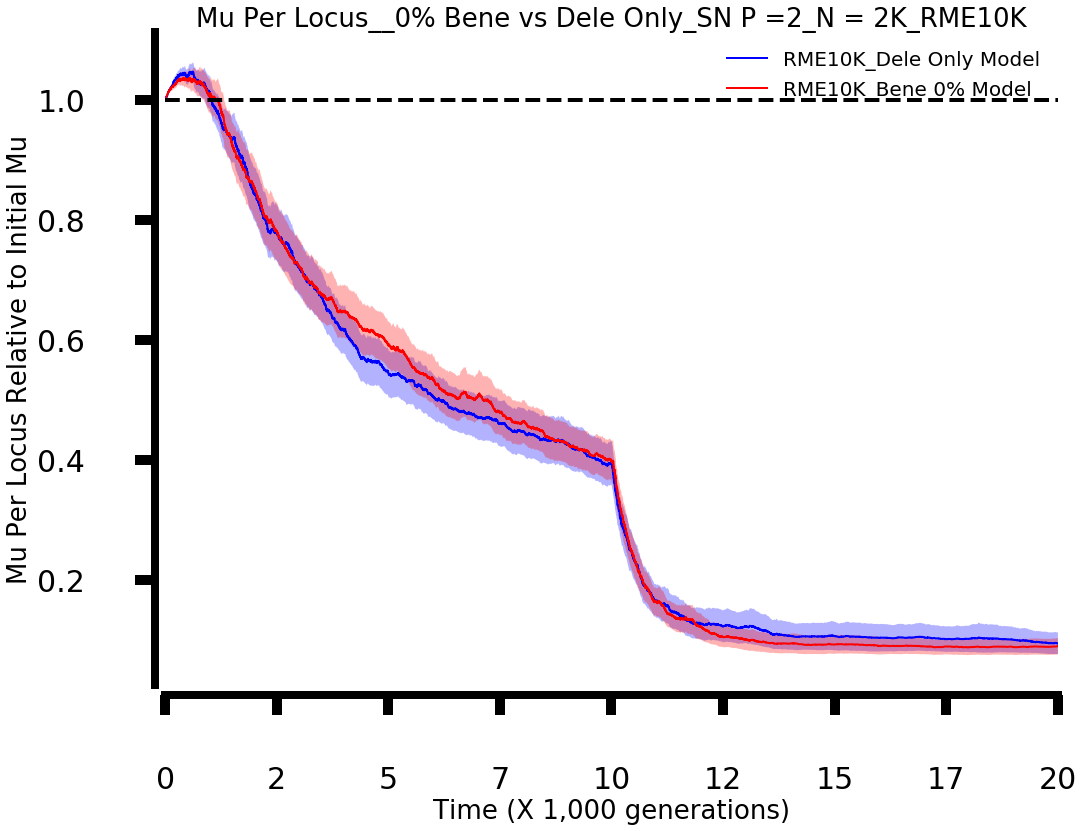

In [12]:
for i in range(6):
    
    
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111)
    publication_figure(ax)

    ax.set_xlim(0,20*1000)


    t = generation_list

    a1 = np.array(bl_sm_mu_mean[i])/(0.1*2/45/(2*100))
    error_a1 = 1.98* np.array(bl_sm_mu_std[i])/((100)**0.5)/(0.1*2/45/(2*100))

    a2 = np.array(f005_sm_mu_dele_mean[i])/(0.1*2/45/(2*100))
    error_a2 = 1.98* np.array(f005_sm_mu_dele_std[i])/((100)**0.5)/(0.1*2/45/(2*100))

    rp_strategy = ['Mito', 'RM', 'RME10', 'RME100', 'RME1K', 'RME10K']


    ax.set_title('Mu Per Locus__0% Bene vs Dele Only_SN P =2_N = 2K_{}'.format(rp_strategy[i]), fontsize =26)
    ax.set_xlabel('Time (X 1,000 generations)', fontsize =26)
    ax.set_ylabel('Mu Per Locus Relative to Initial Mu', fontsize =26)
    
    
    ax.plot(t,a1,'b', label = '{}_Dele Only Model'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='b')


    ax.plot(t,a2,'r', label = '{}_Bene 0% Model'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='r')


 

    plt.axhline(y= 0.1/(45*100)/(0.1/(45*100)), linewidth=4.0, color ='k',ls ='dashed')

    ax.minorticks_off()

    plt.legend(loc=1, frameon=False, prop={'size':20})
    

    plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))